In [7]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 

In [11]:
df=pd.read_csv(r"C:\Users\USER\OneDrive\Documents\diabetes_prediction\diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [13]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

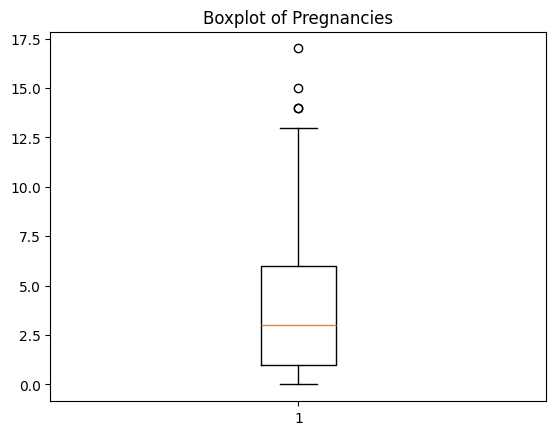

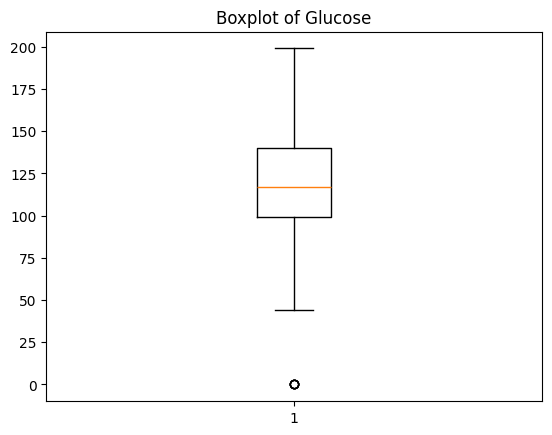

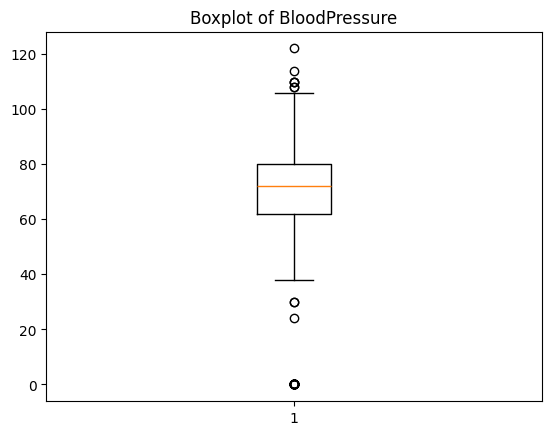

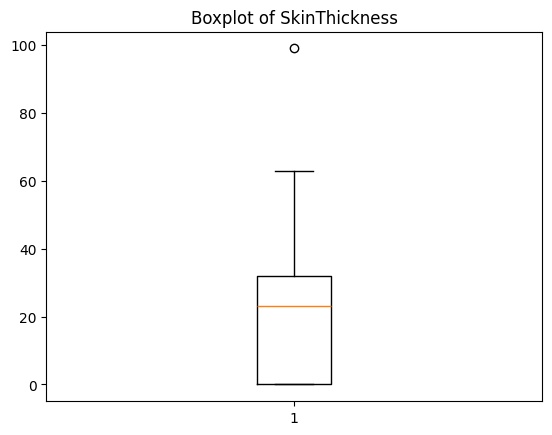

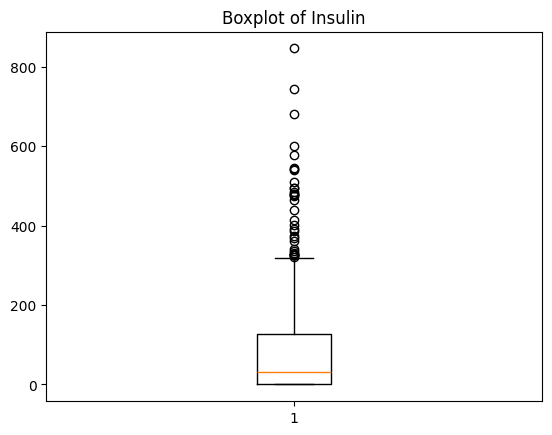

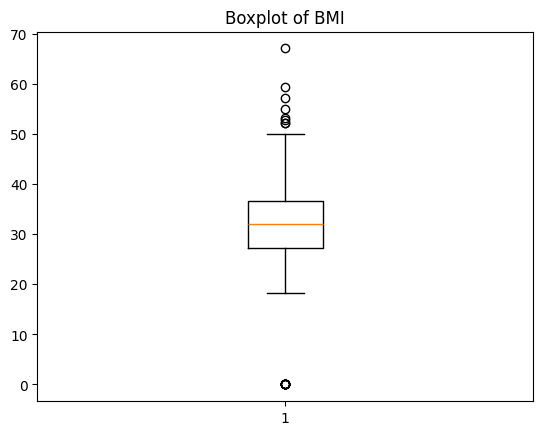

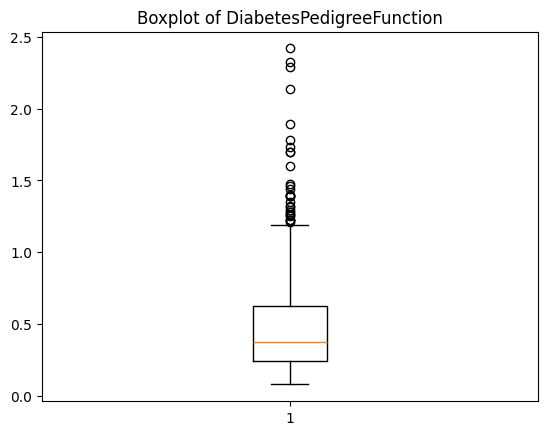

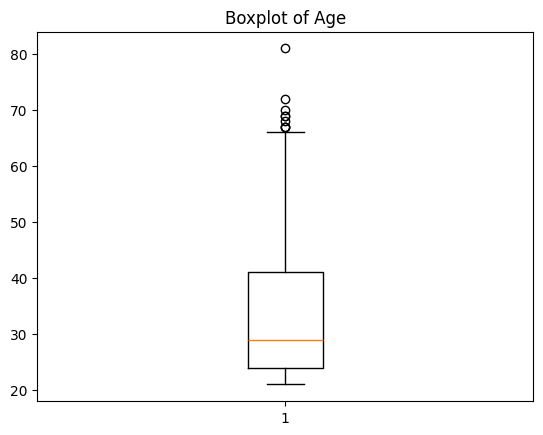

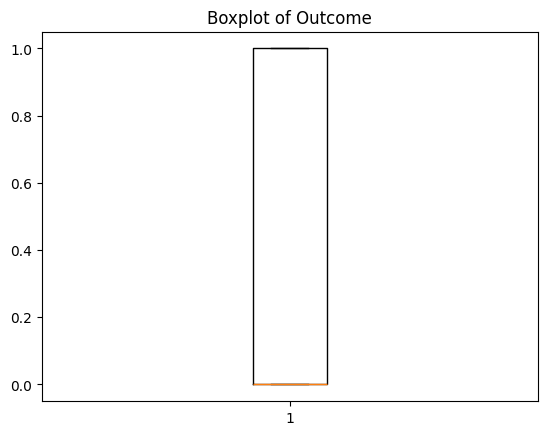

In [14]:
for col in df:
  if df[col].dtype=="int" or df[col].dtype=='float':
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [15]:
x=df.drop(columns=['Outcome'])
y=df['Outcome']

In [16]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [18]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
scalar=MinMaxScaler()
x_scaled=scalar.fit_transform(x)

In [19]:
standard=StandardScaler()
x_scale2=standard.fit_transform(x)
x_scale2.min()

np.float64(-4.060473872668307)

In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.3,random_state=3)
x_train

array([[0.05882353, 0.62311558, 0.60655738, ..., 0.414307  , 0.00939368,
        0.15      ],
       [0.05882353, 0.90954774, 0.52459016, ..., 0.50819672, 0.10674637,
        0.28333333],
       [0.41176471, 0.97487437, 0.55737705, ..., 0.53502235, 0.28479932,
        0.33333333],
       ...,
       [0.23529412, 0.45226131, 0.        , ..., 0.41728763, 0.22715628,
        0.16666667],
       [0.05882353, 0.55778894, 0.70491803, ..., 0.4485842 , 0.02775406,
        0.03333333],
       [0.35294118, 0.57788945, 0.49180328, ..., 0.50223547, 0.07130658,
        0.31666667]])

In [21]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier()
model.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [22]:
y_pred=model.predict(x_test)
y_pred.shape
y_test

51     0
378    1
27     0
579    1
86     0
      ..
467    0
296    1
188    1
132    1
406    1
Name: Outcome, Length: 231, dtype: int64

In [23]:
from sklearn.metrics import accuracy_score
print(f"{round(accuracy_score(y_test,y_pred)*100)} % Accuracy")

69 % Accuracy


In [24]:
from sklearn.svm import SVC
svc_model=SVC()
#kernel="poly","sigmoid","linear","rbf"
svc_model.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [25]:
y_pred_svc=svc_model.predict(x_test)

In [26]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred_svc))

0.7316017316017316


In [27]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[111,  22],
       [ 50,  48]])

In [28]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.69      0.83      0.76       133
           1       0.69      0.49      0.57        98

    accuracy                           0.69       231
   macro avg       0.69      0.66      0.66       231
weighted avg       0.69      0.69      0.68       231



In [31]:
from imblearn.over_sampling import SMOTE
sampler=SMOTE()
x_res,y_res=sampler.fit_resample(x_scaled,y)

In [32]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_res,y_res,test_size=0.3,random_state=42)

In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [44]:
models=[DecisionTreeClassifier(),SVC(),GaussianNB(),KNeighborsClassifier()]
for model in models:
  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
models=[DecisionTreeClassifier(),SVC(),GaussianNB(),KNeighborsClassifier(),RandomForestClassifier()]
for model in models:
  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)
  print(model)
  print("--------------------------------------------------")
  print(f"Accuracy score:{accuracy_score(y_test,y_pred)}")
  print(classification_report(y_test,y_pred))
  print(confusion_matrix(y_test,y_pred))
  print("**************************************************")
  print('\n\n')

DecisionTreeClassifier()
--------------------------------------------------
Accuracy score:0.7633333333333333
              precision    recall  f1-score   support

           0       0.76      0.76      0.76       149
           1       0.76      0.77      0.77       151

    accuracy                           0.76       300
   macro avg       0.76      0.76      0.76       300
weighted avg       0.76      0.76      0.76       300

[[113  36]
 [ 35 116]]
**************************************************



SVC()
--------------------------------------------------
Accuracy score:0.7633333333333333
              precision    recall  f1-score   support

           0       0.78      0.73      0.75       149
           1       0.75      0.79      0.77       151

    accuracy                           0.76       300
   macro avg       0.76      0.76      0.76       300
weighted avg       0.76      0.76      0.76       300

[[109  40]
 [ 31 120]]
*********************************************

In [35]:
from sklearn.model_selection import cross_val_score
cross_val_score(GaussianNB(),x_res,y_res,cv=5).mean()

np.float64(0.748)

In [38]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
dict1={"var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4]}
tuner=GridSearchCV(GaussianNB(),dict1,cv=5)
tuner.fit(x,y)

,estimator,GaussianNB()
,param_grid,"{'var_smoothing': [1e-09, 1e-08, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,priors,None


In [40]:
tuner.best_params_


{'var_smoothing': 1e-06}

In [41]:
tuner.best_params_
 

{'var_smoothing': 1e-06}

In [42]:
tuner.best_estimator_

,priors,None
,var_smoothing,1e-06


In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

dict1 = {
    "n_estimators": [50, 100, 150, 200],
    "criterion": ["gini", "entropy"],
    "max_depth": [10, 20, 30, 40, 50],
    "min_samples_split": [2, 5, 10]
}

tuner = GridSearchCV(
    rf,
    dict1,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

tuner.fit(x_res, y_res)

print("Best Parameters:", tuner.best_params_)
print("Best CV Accuracy:", tuner.best_score_)

best_rf = tuner.best_estimator_

Best Parameters: {'criterion': 'gini', 'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 150}
Best CV Accuracy: 0.825
